# Task 2 – Exploratory Data Analysis (Employee Dataset)
Cleaned dataset from Task 1: 60 employees, 11 columns. Tools: pandas, seaborn, scipy.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
%matplotlib inline
CH=Path("charts"); CH.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", palette="deep"); plt.rcParams.update({"figure.dpi":110,"savefig.bbox":"tight"})
ROOT=Path(".")
df=pd.read_csv("data/cleaned_data.csv", parse_dates=["Join_Date"])
df["Active"]=df["Active"].map({True:True,False:False,"True":True,"False":False})
df.head()

,EmployeeID,Full Name,Age,Gender,Department,City,Join_Date,Salary,Email,Rating,Active
0,E1001,Aditya Verma,38.0,Female,Operations,Surat,2021-05-14,37280.0,aditya.verma78@gmail.com,5.0,False
1,E1002,N. Kumar,47.0,Male,Sales,Bengaluru,2021-05-14,61421.0,nikhil.kumar98@company.com,2.0,False
2,E1003,Sanjay Verma,NaN,Male,Finance,Hyderabad,2021-05-14,107397.0,sanjay.verma91@gmail.com,1.0,NaN
3,E1004,Neha Chopra,NaN,Female,Finance,Chennai,2021-05-14,52460.0,neha.chopra88@gmail.com,NaN,NaN
4,E1005,Anjali Joshi,30.0,Male,IT,Mumbai,2021-05-14,NaN,anjali.joshi28@gmail.com,4.5,False


## 1. Overview & missing values

In [2]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
print("Rows with at least one missing value:", df.isna().any(axis=1).sum(), "of", len(df))
print("Fully complete rows:", len(df.dropna()))
summary = df[["Age", "Salary", "Rating"]].describe().T
summary["skew"] = df[["Age", "Salary", "Rating"]].skew()
summary["missing_%"] = (df[["Age", "Salary", "Rating"]].isna().mean() * 100).round(1)
summary.round(2).to_csv(ROOT / "summary_stats.csv")
print("\n", summary.round(2))



Shape: (60, 11)

Missing values:
 EmployeeID     0
Full Name      0
Age           25
Gender         1
Department     3
City           2
Join_Date      4
Salary        16
Email          7
Rating        16
Active         5
dtype: int64
Rows with at least one missing value: 47 of 60
Fully complete rows: 13

         count      mean       std      min      25%      50%        75%  \
Age      35.0     37.63     11.42     22.0     26.0     36.0      49.50   
Salary   44.0  74470.02  28120.79  26504.0  52120.0  77939.0  100451.75   
Rating   44.0      3.49      1.41      1.0      2.0      3.5       5.00   

             max  skew  missing_%  
Age         57.0  0.28       41.7  
Salary  114889.0 -0.27       26.7  
Rating       5.0 -0.47       26.7  


## 2. Outlier check (IQR)

In [3]:
for c in ["Age", "Salary", "Rating"]:
    s = df[c].dropna()
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    n = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    print(f"IQR outliers in {c}: {n}")



IQR outliers in Age: 0
IQR outliers in Salary: 0
IQR outliers in Rating: 0


## 3. Group statistics

In [4]:
by_dept = df.groupby("Department").agg(n=("EmployeeID", "count"), avg_salary=("Salary", "mean"),
                                       avg_rating=("Rating", "mean"),
                                       inactive_rate=("Active", lambda s: (s == False).sum() / s.notna().sum()))
by_city = df.groupby("City").agg(n=("EmployeeID", "count"), avg_salary=("Salary", "mean"), avg_rating=("Rating", "mean"))
by_gender = df.groupby("Gender").agg(n=("EmployeeID", "count"), avg_salary=("Salary", "mean"), avg_rating=("Rating", "mean"))
df["Join_Year"] = df["Join_Date"].dt.year
by_cohort = df.groupby("Join_Year").agg(n=("EmployeeID", "count"), avg_salary=("Salary", "mean"), avg_rating=("Rating", "mean"))
print("\n", by_dept.round(2), "\n", by_city.round(2), "\n", by_gender.round(2), "\n", by_cohort.round(2))




              n  avg_salary  avg_rating  inactive_rate
Department                                           
Finance      9    77352.00        2.88           0.33
HR          12    83695.22        3.75           0.75
IT           5    73494.33        4.83           0.60
Marketing   10    73043.86        3.29           0.50
Operations  14    68023.18        3.21           0.43
Sales        7    66422.80        4.10           0.71 
            n  avg_salary  avg_rating
City                                
Ahmedabad  5    46337.00        3.62
Bengaluru  8    75876.43        2.67
Chennai    4    64911.67        4.17
Delhi      6    91192.00        3.50
Hyderabad  6    70918.20        3.42
Jaipur     2    63772.00        3.50
Kolkata    3    68404.00        3.00
Mumbai     9    86482.75        3.50
Pune       9    75548.83        3.00
Surat      6    66437.33        4.50 
          n  avg_salary  avg_rating
Gender                            
Female  25    66121.67        3.45
Male    34   

## 4. Hypothesis tests

In [5]:
m, f = (df[df.Gender == g].Salary.dropna() for g in ["Male", "Female"])
print("\nSalary Male vs Female: means", round(m.mean()), round(f.mean()),
      "| Welch t-test p =", round(stats.ttest_ind(m, f, equal_var=False).pvalue, 3))
d = df.dropna(subset=["Salary", "Rating"])
rho, p = stats.spearmanr(d.Salary, d.Rating)
print(f"Salary vs Rating Spearman rho={rho:.2f}, p={p:.2f} (n={len(d)})")




Salary Male vs Female: means 80829 66122 | Welch t-test p = 0.084
Salary vs Rating Spearman rho=0.25, p=0.18 (n=31)


## 5. Charts

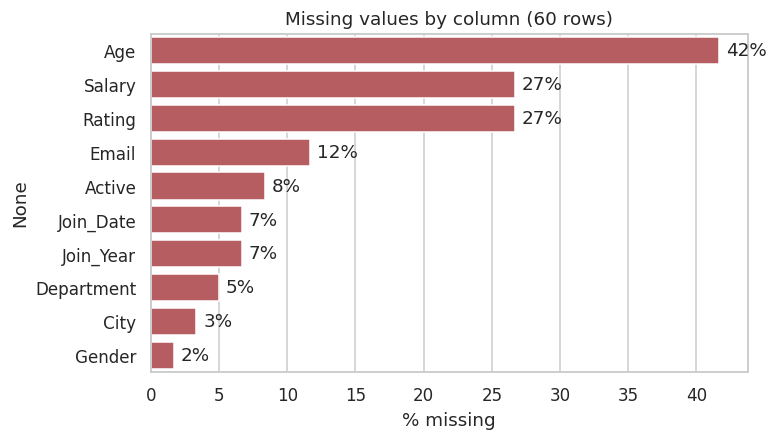

In [6]:
# 5.1 Missing values
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=miss.values, y=miss.index, ax=ax, color="#c44e52")
for i, v in enumerate(miss.values): ax.text(v + .5, i, f"{v:.0f}%", va="center")
ax.set_xlabel("% missing"); ax.set_title("Missing values by column (60 rows)")
fig.savefig(CH / "01_missing_values.png"); plt.show()


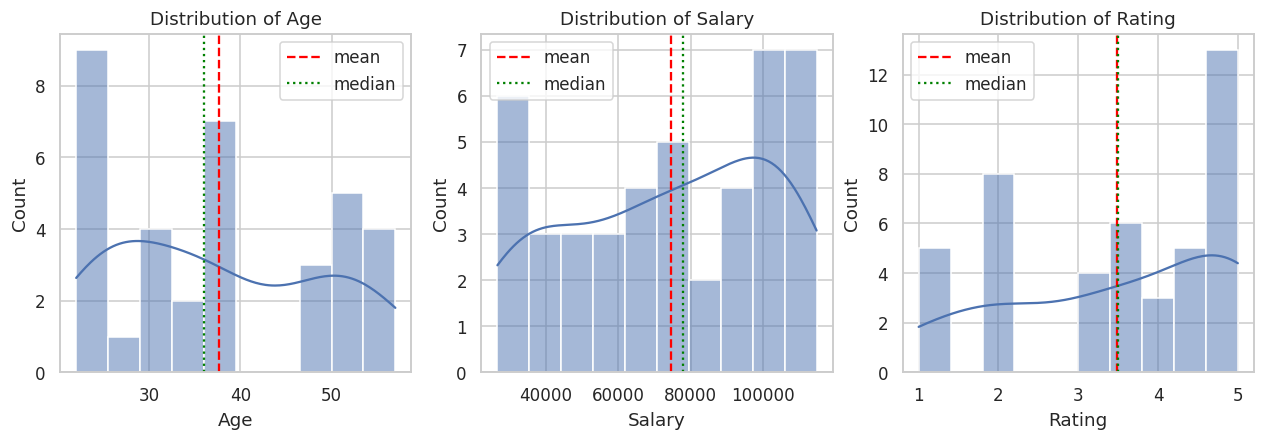

In [7]:
# 5.2 Distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, ["Age", "Salary", "Rating"]):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, bins=10)
    ax.axvline(df[c].mean(), color="red", ls="--", label="mean"); ax.axvline(df[c].median(), color="green", ls=":", label="median")
    ax.set_title(f"Distribution of {c}"); ax.legend()
fig.savefig(CH / "02_distributions.png"); plt.show()


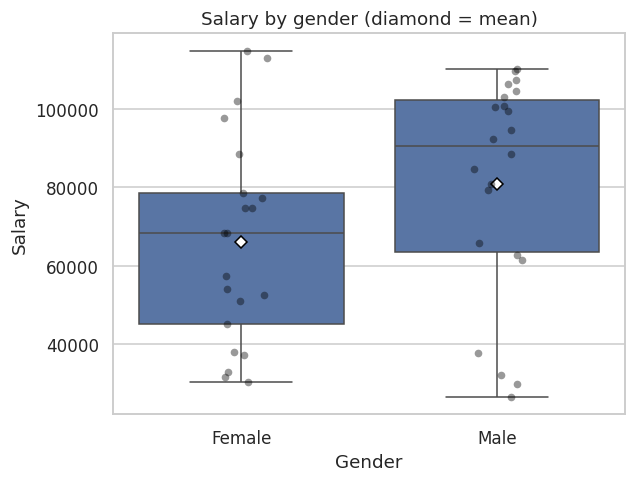

In [8]:
# 5.3 Salary by gender
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df, x="Gender", y="Salary", ax=ax, showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black"})
sns.stripplot(data=df, x="Gender", y="Salary", ax=ax, color="black", alpha=.4)
ax.set_title("Salary by gender (diamond = mean)")
fig.savefig(CH / "03_salary_by_gender.png"); plt.show()


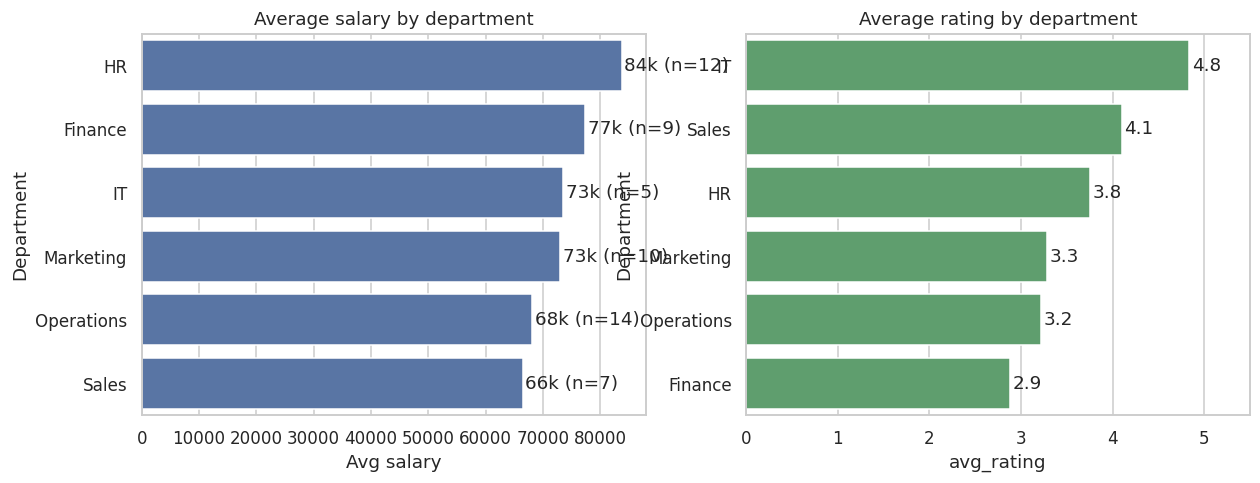

In [9]:
# 5.4 Dept salary & rating
order = by_dept.sort_values("avg_salary", ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=by_dept.loc[order].avg_salary, y=order, ax=axes[0], color="#4c72b0")
for i, (v, n) in enumerate(zip(by_dept.loc[order].avg_salary, by_dept.loc[order].n)): axes[0].text(v + 500, i, f"{v/1000:.0f}k (n={n})", va="center")
axes[0].set_title("Average salary by department"); axes[0].set_xlabel("Avg salary")
o2 = by_dept.sort_values("avg_rating", ascending=False).index
sns.barplot(x=by_dept.loc[o2].avg_rating, y=o2, ax=axes[1], color="#55a868")
for i, v in enumerate(by_dept.loc[o2].avg_rating): axes[1].text(v + .03, i, f"{v:.1f}", va="center")
axes[1].set_title("Average rating by department"); axes[1].set_xlim(0, 5.5)
fig.savefig(CH / "04_department_salary_rating.png"); plt.show()


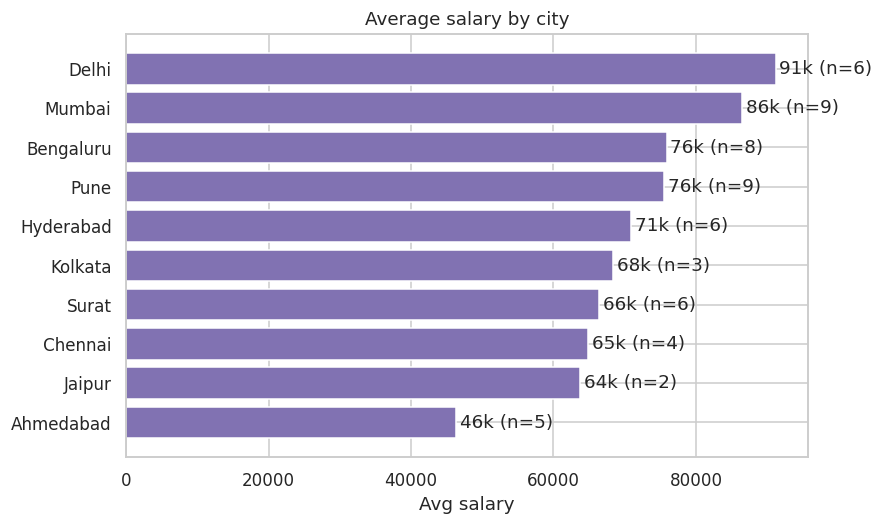

In [10]:
# 5.5 City salary
c = by_city.sort_values("avg_salary")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(c.index, c.avg_salary, color="#8172b2")
for i, (v, n) in enumerate(zip(c.avg_salary, c.n)): ax.text(v + 500, i, f"{v/1000:.0f}k (n={n})", va="center")
ax.set_title("Average salary by city"); ax.set_xlabel("Avg salary")
fig.savefig(CH / "05_city_salary.png"); plt.show()


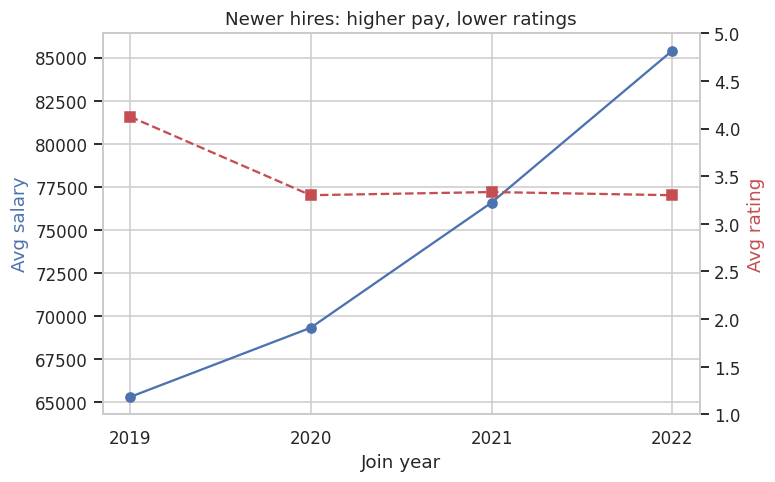

In [11]:
# 5.6 Join cohort trend
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(by_cohort.index, by_cohort.avg_salary, "o-", color="#4c72b0", label="Avg salary")
ax1.set_ylabel("Avg salary", color="#4c72b0"); ax1.set_xticks(by_cohort.index); ax1.set_xlabel("Join year")
ax2 = ax1.twinx(); ax2.plot(by_cohort.index, by_cohort.avg_rating, "s--", color="#c44e52"); ax2.set_ylabel("Avg rating", color="#c44e52"); ax2.set_ylim(1, 5)
ax2.grid(False); ax1.set_title("Newer hires: higher pay, lower ratings")
fig.savefig(CH / "06_join_cohort_trend.png"); plt.show()


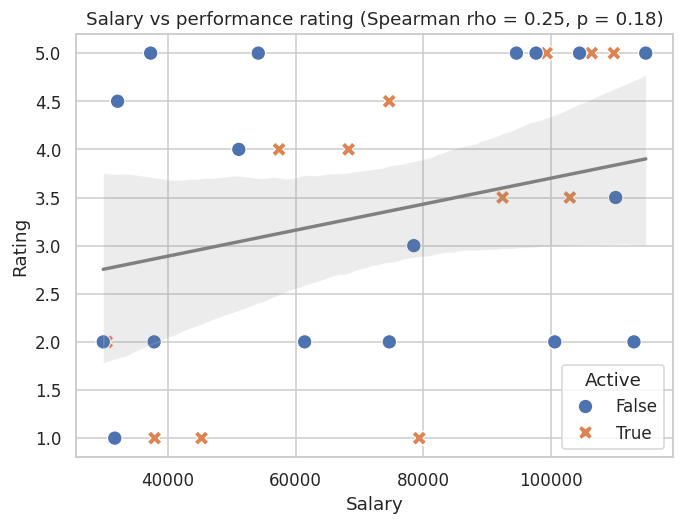

In [12]:
# 5.7 Salary vs rating
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=d, x="Salary", y="Rating", hue="Active", style="Active", s=90, ax=ax)
sns.regplot(data=d, x="Salary", y="Rating", scatter=False, color="gray", ax=ax)
ax.set_title(f"Salary vs performance rating (Spearman rho = {rho:.2f}, p = {p:.2f})")
fig.savefig(CH / "07_salary_vs_rating.png"); plt.show()


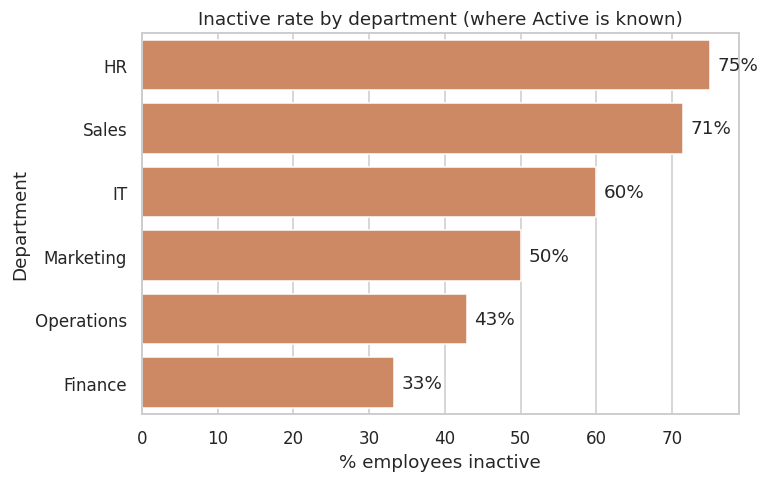

In [13]:
# 5.8 Inactive rate by department
r = by_dept.sort_values("inactive_rate", ascending=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=r.inactive_rate * 100, y=r.index, ax=ax, color="#dd8452")
for i, v in enumerate(r.inactive_rate * 100): ax.text(v + 1, i, f"{v:.0f}%", va="center")
ax.set_xlabel("% employees inactive"); ax.set_title("Inactive rate by department (where Active is known)")
fig.savefig(CH / "08_inactive_by_department.png"); plt.show()


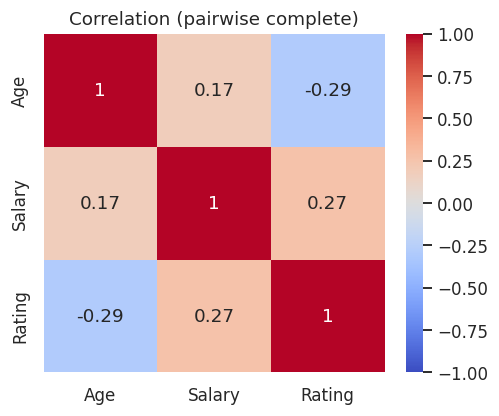

In [14]:
# 5.9 Correlation heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df[["Age", "Salary", "Rating"]].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation (pairwise complete)")
fig.savefig(CH / "09_correlation.png"); plt.show()


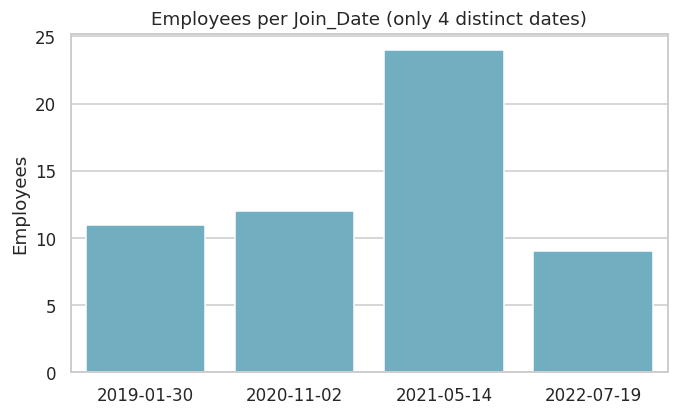

In [15]:
# 5.10 Join date batches
fig, ax = plt.subplots(figsize=(7, 4))
jd = df["Join_Date"].dt.date.value_counts().sort_index()
sns.barplot(x=[str(x) for x in jd.index], y=jd.values, ax=ax, color="#64b5cd")
ax.set_title("Employees per Join_Date (only 4 distinct dates)"); ax.set_ylabel("Employees")
fig.savefig(CH / "10_join_date_batches.png"); plt.show()



## Insights

**1. Data completeness is the biggest limitation.**
Only 13 of 60 rows are fully complete. Age is 42% missing and Salary and Rating are 27% each. Every finding below uses the available rows only and is directional, not conclusive. (`01_missing_values.png`)

**2. Men earn ~22% more on average than women, with no rating difference.**
Mean salary is 80.8k for men (n=22) and 66.1k for women (n=21). Average ratings are almost identical (3.46 vs 3.45). The gap is not statistically significant at 5% (Welch t-test p = 0.084), but it is worth an HR pay-equity review. (`03_salary_by_gender.png`)

**3. Pay is only weakly linked to performance.**
Salary and Rating have a Spearman correlation of 0.25 (p = 0.18, n = 31). Examples: 3 employees earn above 90k with a rating of 2 or below, and 3 earn under 45k with a rating of 4.5 or above. Pay bands do not appear to reward performance. (`07_salary_vs_rating.png`, `09_correlation.png`)

**4. Newer cohorts are paid more but rated lower (pay compression).**
Average salary rises with each join year: 65k (2019), 69k (2020), 77k (2021), 85k (2022). Average rating falls from 4.1 for the 2019 cohort to about 3.3 for the later three. Recent hires appear to be brought in at higher pay than longer-serving staff. (`06_join_cohort_trend.png`)

**5. Department and city differ noticeably.**
- HR has the highest average salary (83.7k) and Sales the lowest (66.4k).
- IT has the top rating (4.8, only 5 people) and Finance the lowest (2.9).
- Delhi (91k) and Mumbai (86k) pay the most, while Ahmedabad pays the least (46k, n=3).
- Bengaluru has the lowest city rating (2.7) despite an above-average salary of 76k.

Sales (4.1 rating, lowest pay) and Surat (4.5 rating, below-average pay of 66k) are rated highly despite low pay, so pay does not track rating across groups either. Small group sizes (n = 3–14) mean these are indicative only. (`04_department_salary_rating.png`, `05_city_salary.png`)

**6. More than half of employees are marked inactive, and it varies by department.**
30 of 55 employees with a known status (55%) are inactive. Rates are highest in HR (75%) and Sales (71%) and lowest in Finance (33%). Inactive employees are younger on average (34.7 vs 40.5 years) and have slightly higher ratings (3.6 vs 3.3, not significant, p = 0.46). This suggests attrition may be losing younger, well-rated staff. (`08_inactive_by_department.png`)

## Anomalies and data-quality flags
- **Join_Date looks batch-loaded:** only 4 distinct dates exist, and 24 of 60 employees (40%) share 2021-05-14, which may be a default or import date. (`10_join_date_batches.png`)
- **Age has a spike at 25:** 6 employees are aged 25 (the mode), which may be imputed or defaulted values.
- **Gender and name mismatches:** e.g. "Aditya Verma" is Female and "Neha Gupta" is Male, so the Gender field should be verified with the source before gender conclusions are relied on.
- **Abbreviated names** (e.g. "N. Kumar", "S. Rao") remain, although the email addresses reveal the full name (nikhil.kumar98@…). There are also 2 employees named "Sneha Joshi" with different IDs, so they are not duplicates.
- **Wide salary range:** the minimum is 26.5k and the maximum 114.9k, with no true statistical outliers.

## Recommendations
1. Fix the source-data gaps (Age, Salary, Rating, Join_Date) before deeper modelling.
2. Audit pay by gender and by cohort.
3. Investigate why HR and Sales have high inactivity.
4. Introduce performance-linked pay bands.
